# TB-DOTS CAR CDSS — XGBoost Treatment Outcome Prediction

This notebook trains and compares **two XGBoost** variants for predicting TB treatment outcome (**Success / Failure**) using monthly patient monitoring data and baseline clinical features:

1. **XGBoost (Baseline)** — no augmentation
2. **XGBoost + SMOTE-ENN** — with SMOTE + Edited Nearest Neighbors cleaning

Both models use the same **progressive temporal feature engineering** and **70/20/10 patient-level split** (identical to the other model notebooks) for fair comparison.

### Data Augmentation & Class Imbalance Handling
To address the severe class imbalance (~90% Success / ~10% Failure):
- **SMOTE-ENN** (Synthetic Minority Oversampling + Edited Nearest Neighbors) — generates synthetic Failure samples, then removes noisy/borderline samples via ENN cleaning
- **Native class weighting** — `scale_pos_weight`
- **Threshold optimization** — finds optimal classification threshold on validation set

### Progressive Temporal Prediction
Each model supports **prediction at any month** (M0–M12). For each month `t`, features include:
- **Static features** (51 baseline clinical features)
- **Temporal features up to month t** (flattened + aggregates + trends)

### Outputs
- Trained model checkpoints → `models/Temporal/output/xgboost/xgb_*.json`
- Evaluation report → `models/Temporal/output/xgboost/xgb_evaluation_report.txt`
- Per-patient predictions → `models/Temporal/output/xgboost/xgb_predictions.csv`
- Per-month performance plots
- Feature importance plot
- Metrics/config files


## 0. Imports & Configuration

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths ───────────────────────────────────────────────────────
REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "dataset").exists() and (p / "models").exists()),
    Path.cwd(),
)
BASE_DIR = REPO_ROOT
DATA_DIR = REPO_ROOT / "dataset" / "temporal"
MODEL_DIR = REPO_ROOT / "models" / "Temporal" / "v2" / "output" / "xgboost"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"XGBoost : {xgb.__version__}")
print(f"Data    : {DATA_DIR}")
print(f"Models  : {MODEL_DIR}")


XGBoost : 3.2.0
Data    : c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\dataset\temporal
Models  : c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\xgboost


## 1. Data Loading & Label Creation

Load the same preprocessed temporal and static arrays. Outcome columns are removed from static features to prevent target leakage. Binary labels:
- **Success (1)** = Cured, Treatment Completed
- **Failure (0)** = Died, Lost to Follow-Up, Not Evaluated

In [2]:
def load_data():
    """Load cleaned human-readable CSV via model_utils and return unscaled arrays + labels.

    Scalings are performed after patient-level splitting to avoid leakage.
    """
    import sys
    sys.path.append(str(BASE_DIR / "models" / "Temporal"))
    import model_utils as mu

    csv_path = DATA_DIR / "combined_complete_dataset.csv"
    model_data = mu.load_cleaned_csv(str(csv_path))

    X_temporal = model_data["X_temporal"]
    X_static = model_data["X_static"]
    static_names = list(model_data["static_feature_names"] )
    temporal_names = list(model_data["temporal_feature_names"] )

    # Remove any outcome columns from static features
    outcome_prefix = "outcome_"
    outcome_cols = [c for c in static_names if c.startswith(outcome_prefix)]
    if outcome_cols:
        outcome_idx = [static_names.index(c) for c in outcome_cols]
        keep_idx = [i for i in range(X_static.shape[1]) if i not in outcome_idx]
        X_static_clean = X_static[:, keep_idx]
        static_names_clean = [static_names[i] for i in keep_idx]
    else:
        X_static_clean = X_static
        static_names_clean = static_names

    # --- Build binary labels ---
    df = pd.read_csv(csv_path)
    df.columns = [mu.pp.standardize_column_name(c) for c in df.columns]
    success_outcomes = {"Cured", "Treatment Completed"}
    y = np.array([1 if o in success_outcomes else 0 for o in df["outcome"]], dtype=np.float32)

    print(f"Temporal features : {X_temporal.shape}")
    print(f"Static features   : {X_static_clean.shape}  (outcome cols removed if any)")
    print(f"Labels            : {y.shape}  (Success={int(y.sum())}, Failure={int(len(y) - y.sum())})")

    return X_temporal, X_static_clean, y, static_names_clean, temporal_names, df


X_temporal, X_static, y, static_names, temporal_names, df = load_data()

STAGE 3: Data Cleaning & Type Coercion
  Parsed 'date_of_birth': 573/599 valid, 26 filled with median (1975-10-23)
  Parsed 'date_of_diagnosis': 477/599 valid, 122 filled with median (2023-08-29)
  Parsed 'date_of_notification': 432/599 valid, 167 filled with median (2023-09-23)
  Parsed 'treatment_start_date': 541/599 valid, 58 filled with median (2023-08-19)
  Parsed 'date_of_outcome': 355/599 valid, 244 filled with median (2023-12-03)
  Parsed 'intensive_phase_start_date': 461/599 valid, 138 filled with median (2023-10-11)
  Parsed 'intensive_phase_end_date': 381/599 valid, 218 filled with median (2023-12-08)
  Parsed 'continuation_phase_start_date': 359/599 valid, 240 filled with median (2023-12-09)
  Parsed 'continuation_phase_end_date': 367/599 valid, 232 filled with median (2024-03-21)
  Fixed 1 future DOBs by subtracting 100 years
  Fixed 2 historically implausible DOBs (pre-1920) by adding 100 years
  Fixed 29 future dates in 'date_of_diagnosis' by subtracting 10 years
  Fixed

## 2. Feature Engineering for XGBoost

XGBoost requires flat 2D input, so we transform the 3D temporal data into meaningful engineered features at each prediction month. For month `t`, we compute:

**From temporal data (M0..Mt):**
- Raw features at each available month (flattened)
- **Aggregates**: mean, std, min, max of key temporal features across available months
- **Trend features**: slope of weight, adherence, and cumulative doses over time
- **Latest values**: most recent month's readings

This gives XGBoost rich temporal information without needing a recurrent architecture.

In [3]:
def build_features_at_month(X_temporal, X_static, up_to_month, temporal_names, static_names):
    """
    Build a flat feature matrix for XGBoost using data up to `up_to_month`.

    Features include:
    1. Static baseline features (always the same)
    2. Flattened raw temporal features up to month t
    3. Aggregate stats (mean, std, min, max) over available months
    4. Trend (linear slope) of key features
    5. Latest month's values
    6. Month indicator (how much data is available)

    Returns: X_flat (n_patients, n_features), feature_name_list
    """
    n_patients = X_temporal.shape[0]
    n_temporal_feats = X_temporal.shape[2]  # 8
    valid_months = up_to_month + 1

    feature_list = []
    feature_name_list = []

    # 1. Static features (always included)
    feature_list.append(X_static)
    feature_name_list.extend(static_names)

    # 2. Flattened temporal features for months 0..up_to_month
    temporal_flat = X_temporal[:, :valid_months, :].reshape(n_patients, -1)
    for m in range(valid_months):
        for feat in temporal_names:
            feature_name_list.append(f"M{m}_{feat}")
    feature_list.append(temporal_flat)

    # 3. Aggregate statistics over available months
    temporal_slice = X_temporal[:, :valid_months, :]  # (N, valid_months, 8)
    for agg_name, agg_fn in [("mean", np.mean), ("std", np.std),
                              ("min", np.min), ("max", np.max)]:
        agg = agg_fn(temporal_slice, axis=1)  # (N, 8)
        feature_list.append(agg)
        for feat in temporal_names:
            feature_name_list.append(f"{agg_name}_{feat}")

    # 4. Trend features (linear slope) for key temporal features
    if valid_months >= 2:
        slopes = np.zeros((n_patients, n_temporal_feats))
        x_time = np.arange(valid_months, dtype=np.float32)
        for i in range(n_patients):
            for j in range(n_temporal_feats):
                vals = temporal_slice[i, :, j]
                if np.std(vals) > 1e-8:
                    slope = np.polyfit(x_time, vals, 1)[0]
                else:
                    slope = 0.0
                slopes[i, j] = slope
        feature_list.append(slopes)
        for feat in temporal_names:
            feature_name_list.append(f"trend_{feat}")
    else:
        # With only M0, slope is 0
        feature_list.append(np.zeros((n_patients, n_temporal_feats)))
        for feat in temporal_names:
            feature_name_list.append(f"trend_{feat}")

    # 5. Latest month's values
    latest = X_temporal[:, up_to_month, :]  # (N, 8)
    feature_list.append(latest)
    for feat in temporal_names:
        feature_name_list.append(f"latest_{feat}")

    # 6. Month indicator
    month_indicator = np.full((n_patients, 1), up_to_month, dtype=np.float32)
    feature_list.append(month_indicator)
    feature_name_list.append("months_available")

    X_flat = np.hstack(feature_list).astype(np.float32)
    # Replace any NaN from std calculations (single-month std = nan)
    X_flat = np.nan_to_num(X_flat, nan=0.0)

    return X_flat, feature_name_list


# Demo: build features at M12 (full data) to check dimensions
X_full, feat_names_full = build_features_at_month(
    X_temporal, X_static, up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)
print(f"Full feature matrix (M12): {X_full.shape}")
print(f"Number of features: {len(feat_names_full)}")
print(f"\nFeature name samples:")
print(f"  Static:    {feat_names_full[:3]}")
print(f"  Temporal:  {feat_names_full[len(static_names):len(static_names)+3]}")
print(f"  Aggregate: {[f for f in feat_names_full if f.startswith('mean_')][:3]}")
print(f"  Trend:     {[f for f in feat_names_full if f.startswith('trend_')][:3]}")
print(f"  Latest:    {[f for f in feat_names_full if f.startswith('latest_')][:3]}")

Full feature matrix (M12): (599, 1139)
Number of features: 1139

Feature name samples:
  Static:    ['age', 'xpert_mtb_rif', 'smear_microscopy']
  Temporal:  ['M0_cumulative_doses_taken', 'M0_height', 'M0_monthly_doses_taken']
  Aggregate: ['mean_cumulative_doses_taken', 'mean_height', 'mean_monthly_doses_taken']
  Trend:     ['trend_cumulative_doses_taken', 'trend_height', 'trend_monthly_doses_taken']
  Latest:    ['latest_cumulative_doses_taken', 'latest_height', 'latest_monthly_doses_taken']


## 3. Patient-Level Train/Val/Test Split

Same 70/20/10 patient-level split as the LSTM model (same random seed) for a fair comparison. Split is done on patients first, then features are built per month as needed.

In [4]:
def split_patients(y, seed=42):
    """
    Split patients 70/20/10 — same split as LSTM model for fair comparison.
    Returns patient indices for train, val, test.
    """
    indices = np.arange(len(y))

    # First split: 70% train, 30% temp
    train_idx, rest_idx = train_test_split(
        indices, test_size=0.30, random_state=seed, stratify=y
    )
    # Second split: 20% val, 10% test
    val_idx, test_idx = train_test_split(
        rest_idx, test_size=1 / 3, random_state=seed, stratify=y[rest_idx]
    )

    for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
        yi = y[idx]
        print(f"  {name:>5s}: {len(idx)} patients  "
              f"(Success={int(yi.sum())}, Failure={int(len(yi) - yi.sum())})")

    return train_idx, val_idx, test_idx


print("Patient split (identical to LSTM model):")
train_idx, val_idx, test_idx = split_patients(y, seed=SEED)

Patient split (identical to LSTM model):
  Train: 419 patients  (Success=245, Failure=174)
    Val: 120 patients  (Success=70, Failure=50)
   Test: 60 patients  (Success=35, Failure=25)


## 4. XGBoost Training — Baseline vs Augmented (SMOTE-ENN)

Train XGBoost **twice**: once without augmentation (baseline) and once with SMOTE-ENN.

### SMOTE-ENN Pipeline
1. **SMOTE** — generates synthetic minority (Failure) samples in feature space
2. **Edited Nearest Neighbors (ENN)** — removes noisy/borderline samples whose class label disagrees with the majority of their k-nearest neighbors

Both variants use **progressive temporal data**: for each patient, we create training samples at every month M0–M12, expanding 143 train patients → 1,859 samples.

### Hyperparameters (same for both)
- `max_depth=4`, `min_child_weight=3` (shallow, regularized)
- `subsample=0.8`, `colsample_bytree=0.8` (bagging)
- `n_estimators=300` with early stopping

In [5]:
import sys
sys.path.append(str(BASE_DIR / "dataset" / "temporal"))
import model_utils as mu

scaled = mu.scale_full_arrays(X_static, X_temporal, train_idx)
X_static = scaled["X_static_scaled"]
X_temporal = scaled["X_temporal_scaled"]
mu.save_scalers(scaled["scaler_static"], scaled["scaler_temporal"], str(DATA_DIR))

print(f"Scaled arrays: X_temporal={X_temporal.shape}, X_static={X_static.shape}")
print(f"Split sizes: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

Scaled arrays: X_temporal=(599, 13, 8), X_static=(599, 986)
Split sizes: train=419, val=120, test=60


In [6]:
def build_progressive_data(X_temporal, X_static, y, patient_indices,
                          temporal_names, static_names,
                          min_month=0, max_month=12):
    """
    Build progressive training data: for each patient in patient_indices,
    create one sample per month from min_month to max_month.

    Because XGBoost needs a fixed feature width, we always build features
    as if we have data up to M12 (max possible), but zero-pad future months.
    The feature engineering handles this gracefully via aggregates/trends.
    """
    all_X = []
    all_y = []

    for month in range(min_month, max_month + 1):
        # Build features using only data up to this month
        X_month, feat_names = build_features_at_month(
            X_temporal[patient_indices],
            X_static[patient_indices],
            up_to_month=month,
            temporal_names=temporal_names,
            static_names=static_names,
        )
        all_X.append(X_month)
        all_y.append(y[patient_indices])

    return all_X, all_y, feat_names


def train_xgboost(X_temporal, X_static, y, train_idx, val_idx,
                   temporal_names, static_names, apply_smote=True,
                   save_name="xgb_best_model.json"):
    """
    Train XGBoost with progressive temporal data.

    When apply_smote=True, SMOTE-ENN is applied on the progressive training
    data to generate synthetic minority (Failure) samples and then clean
    noisy/borderline samples using Edited Nearest Neighbors.
    """
    # Build full-length (M12) features for train and val
    X_train_full, feat_names = build_features_at_month(
        X_temporal[train_idx], X_static[train_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
    )
    y_train = y[train_idx]

    X_val_full, _ = build_features_at_month(
        X_temporal[val_idx], X_static[val_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
    )
    y_val = y[val_idx]

    # Build progressive train data (M0–M12 for each patient)
    X_train_prog = []
    y_train_prog = []
    for month in range(13):
        X_m, fn = build_features_at_month(
            X_temporal[train_idx], X_static[train_idx],
            up_to_month=month,
            temporal_names=temporal_names,
            static_names=static_names,
        )
        # Pad to match M12 feature width
        if X_m.shape[1] < X_train_full.shape[1]:
            pad_width = X_train_full.shape[1] - X_m.shape[1]
            X_m = np.hstack([X_m, np.zeros((X_m.shape[0], pad_width), dtype=np.float32)])
        X_train_prog.append(X_m)
        y_train_prog.append(y[train_idx])

    X_train_all = np.vstack(X_train_prog)
    y_train_all = np.concatenate(y_train_prog)

    smote_label = "SMOTE-ENN" if apply_smote else "Baseline"
    print(f"\n{'='*55}")
    print(f"  XGBoost ({smote_label})")
    print(f"{'='*55}")
    print(f"Progressive training samples: {X_train_all.shape[0]} "
          f"({len(train_idx)} patients × 13 months)")
    print(f"Feature dimensions: {X_train_all.shape[1]}")

    # ── Apply SMOTE-ENN for minority oversampling + ENN cleaning ─
    if apply_smote:
        n_minority = int((y_train_all == 0).sum())
        n_majority = int((y_train_all == 1).sum())
        print(f"\nBefore SMOTE-ENN: Success={n_majority}, Failure={n_minority}")

        k = min(5, n_minority - 1)
        if k >= 1:
            smote_enn = SMOTEENN(
                smote=SMOTE(random_state=SEED, k_neighbors=k),
                random_state=SEED,
            )
            X_train_all, y_train_all = smote_enn.fit_resample(X_train_all, y_train_all)

            n_minority_after = int((y_train_all == 0).sum())
            n_majority_after = int((y_train_all == 1).sum())
            print(f"After SMOTE-ENN:  Success={n_majority_after}, Failure={n_minority_after}")
            print(f"Total training samples: {len(y_train_all)} "
                  f"(SMOTE oversampled + ENN cleaned)")
        else:
            print(f"SMOTE-ENN skipped: not enough minority samples (k_neighbors={k})")
    else:
        print(f"\nSMOTE-ENN disabled (baseline)")

    print(f"Validation samples: {X_val_full.shape[0]}")

    # Class imbalance weight
    n_pos = y_train_all.sum()
    n_neg = len(y_train_all) - n_pos
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

    print(f"Class balance: Success={int(n_pos)}, Failure={int(n_neg)}, "
          f"scale_pos_weight={scale_pos_weight:.2f}")

    # ── XGBoost model ────────────────────────────────────────────
    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        early_stopping_rounds=20,
        random_state=SEED,
        use_label_encoder=False,
        verbosity=0,
    )

    model.fit(
        X_train_all, y_train_all,
        eval_set=[(X_train_all, y_train_all), (X_val_full, y_val)],
        verbose=False,
    )

    results = model.evals_result()
    history = {
        "train_loss": results["validation_0"]["logloss"],
        "val_loss": results["validation_1"]["logloss"],
    }

    model.save_model(str(MODEL_DIR / save_name))
    print(f"Best iteration: {model.best_iteration} / {model.n_estimators}")
    print(f"Model saved to models/{save_name}")

    return model, history, feat_names


# ── Train Baseline XGBoost (no SMOTE-ENN) ───────────────────────
xgb_baseline_model, xgb_baseline_history, feature_names_xgb = train_xgboost(
    X_temporal, X_static, y, train_idx, val_idx,
    temporal_names, static_names,
    apply_smote=False,
    save_name="xgb_baseline_model.json",
)

# ── Train Augmented XGBoost (with SMOTE-ENN) ────────────────────
xgb_smote_model, xgb_smote_history, _ = train_xgboost(
    X_temporal, X_static, y, train_idx, val_idx,
    temporal_names, static_names,
    apply_smote=True,
    save_name="xgb_smote_model.json",
)


  XGBoost (Baseline)
Progressive training samples: 5447 (419 patients × 13 months)
Feature dimensions: 1139

SMOTE-ENN disabled (baseline)
Validation samples: 120
Class balance: Success=3185, Failure=2262, scale_pos_weight=0.71
Best iteration: 77 / 300
Model saved to models/xgb_baseline_model.json

  XGBoost (SMOTE-ENN)
Progressive training samples: 5447 (419 patients × 13 months)
Feature dimensions: 1139

Before SMOTE-ENN: Success=3185, Failure=2262


  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                    

After SMOTE-ENN:  Success=3143, Failure=3141
Total training samples: 6284 (SMOTE oversampled + ENN cleaned)
Validation samples: 120
Class balance: Success=3143, Failure=3141, scale_pos_weight=1.00
Best iteration: 101 / 300
Model saved to models/xgb_smote_model.json


### Training Curves — Baseline vs SMOTE-ENN

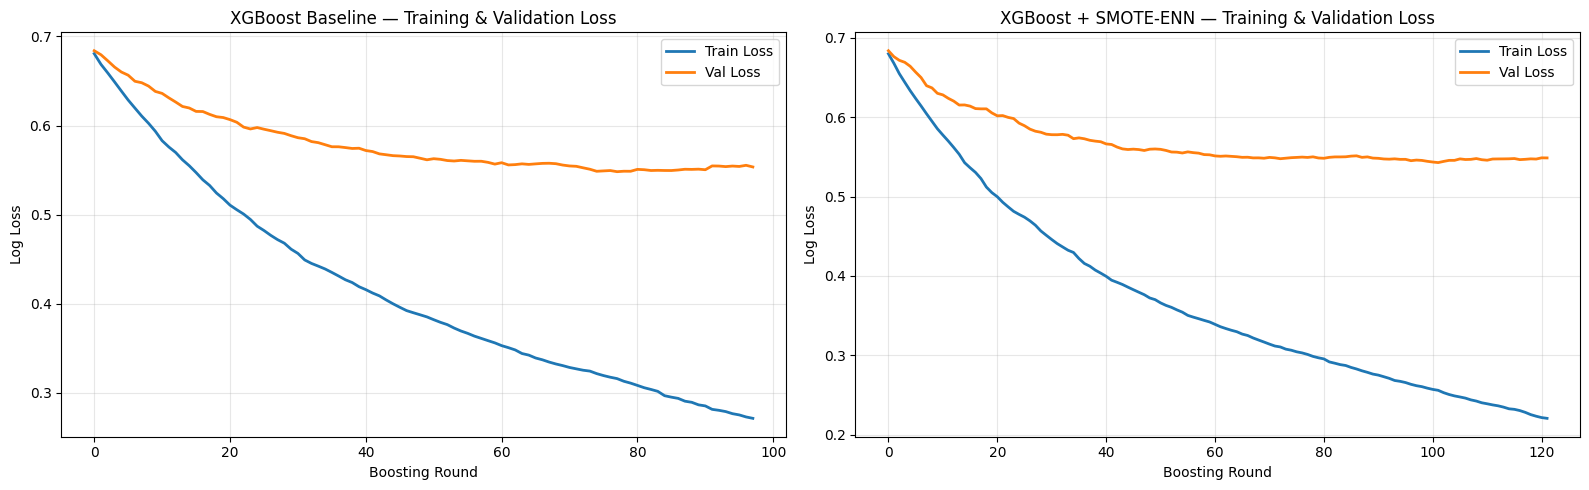

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, hist, title in [(axes[0], xgb_baseline_history, "XGBoost Baseline"),
                          (axes[1], xgb_smote_history, "XGBoost + SMOTE-ENN")]:
    ax.plot(hist["train_loss"], label="Train Loss", linewidth=2)
    ax.plot(hist["val_loss"], label="Val Loss", linewidth=2)
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel("Log Loss")
    ax.set_title(f"{title} — Training & Validation Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / "xgb_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Evaluation — Baseline vs SMOTE-ENN XGBoost

Evaluate both XGBoost variants on the held-out **10% test set** using full M0–M12 data, with **optimized classification threshold** from validation set.

In [8]:
def predict_at_month_xgb(model, X_temporal_subset, X_static_subset,
                        up_to_month, temporal_names, static_names,
                        n_features_full):
    """
    Generate predictions using data up to a specific month.
    Pads feature vector to match the full M12 width the model was trained on.
    """
    X_month, _ = build_features_at_month(
        X_temporal_subset, X_static_subset,
        up_to_month=up_to_month,
        temporal_names=temporal_names,
        static_names=static_names,
    )
    if X_month.shape[1] < n_features_full:
        pad_width = n_features_full - X_month.shape[1]
        X_month = np.hstack([X_month, np.zeros((X_month.shape[0], pad_width),
                                                dtype=np.float32)])
    probs = model.predict_proba(X_month)[:, 1]
    return probs


def find_optimal_threshold_xgb(model, X_temporal, X_static, y, val_idx,
                                temporal_names, static_names, n_features_full):
    """
    Find the optimal classification threshold on the validation set.
    Maximizes a combination of F1 and specificity.
    """
    probs = predict_at_month_xgb(
        model, X_temporal[val_idx], X_static[val_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )
    labels = y[val_idx]

    best_score = 0
    best_thresh = 0.5
    thresholds = np.arange(0.1, 0.9, 0.01)

    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        spec = recall_score(labels, preds, pos_label=0, zero_division=0)
        combined = f1 * 0.6 + spec * 0.4
        if combined > best_score:
            best_score = combined
            best_thresh = t

    return best_thresh


def evaluate_model_xgb(model, X_temporal, X_static, y, test_idx,
                       temporal_names, static_names, n_features_full,
                       threshold=0.5):
    """Full evaluation on held-out test set using M12 data."""
    probs = predict_at_month_xgb(
        model, X_temporal[test_idx], X_static[test_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )
    labels = y[test_idx]
    preds = (probs >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "specificity": recall_score(labels, preds, pos_label=0, zero_division=0),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(labels, probs)
    except ValueError:
        metrics["roc_auc"] = float("nan")
    try:
        metrics["pr_auc"] = average_precision_score(labels, probs)
    except ValueError:
        metrics["pr_auc"] = float("nan")

    cm = confusion_matrix(labels, preds)
    return probs, preds, labels, metrics, cm


def evaluate_per_month_xgb(model, X_temporal_subset, X_static_subset,
                           y_subset, temporal_names, static_names,
                           n_features_full, threshold=0.5):
    """Evaluate model accuracy at each month (M0–M12) for test patients."""
    month_metrics = []
    for month in range(13):
        probs = predict_at_month_xgb(
            model, X_temporal_subset, X_static_subset,
            up_to_month=month,
            temporal_names=temporal_names,
            static_names=static_names,
            n_features_full=n_features_full,
        )
        preds = (probs >= threshold).astype(int)
        acc = accuracy_score(y_subset, preds)
        f1 = f1_score(y_subset, preds, zero_division=0)
        spec = recall_score(y_subset, preds, pos_label=0, zero_division=0)
        try:
            auc = roc_auc_score(y_subset, probs)
        except ValueError:
            auc = float("nan")

        month_metrics.append({
            "month": f"M{month}", "accuracy": acc,
            "f1": f1, "specificity": spec, "auc": auc,
            "n_correct": int((preds == y_subset).sum()),
            "n_total": len(y_subset),
        })
    return pd.DataFrame(month_metrics)


# ── Feature count at M12 ────────────────────────────────────────
n_features_full = build_features_at_month(
    X_temporal[:1], X_static[:1], 12, temporal_names, static_names
)[0].shape[1]

# ── Evaluate BASELINE XGBoost ───────────────────────────────────
print("=" * 60)
print("  XGBoost BASELINE (no SMOTE-ENN)")
print("=" * 60)
xgb_baseline_thresh = find_optimal_threshold_xgb(
    xgb_baseline_model, X_temporal, X_static, y, val_idx,
    temporal_names, static_names, n_features_full
)
print(f"Optimal threshold: {xgb_baseline_thresh:.2f}")

xgb_bl_probs, xgb_bl_preds, xgb_bl_labels, xgb_baseline_metrics, xgb_bl_cm = evaluate_model_xgb(
    xgb_baseline_model, X_temporal, X_static, y, test_idx,
    temporal_names, static_names, n_features_full,
    threshold=xgb_baseline_thresh,
)
for k, v in xgb_baseline_metrics.items():
    print(f"  {k:<14s} : {v:.4f}")
print(f"\nConfusion Matrix:\n{xgb_bl_cm}")

# ── Evaluate SMOTE-ENN XGBoost ──────────────────────────────────
print("\n" + "=" * 60)
print("  XGBoost + SMOTE-ENN")
print("=" * 60)
xgb_smote_thresh = find_optimal_threshold_xgb(
    xgb_smote_model, X_temporal, X_static, y, val_idx,
    temporal_names, static_names, n_features_full
)
print(f"Optimal threshold: {xgb_smote_thresh:.2f}")

xgb_sm_probs, xgb_sm_preds, xgb_sm_labels, xgb_smote_metrics, xgb_sm_cm = evaluate_model_xgb(
    xgb_smote_model, X_temporal, X_static, y, test_idx,
    temporal_names, static_names, n_features_full,
    threshold=xgb_smote_thresh,
)
for k, v in xgb_smote_metrics.items():
    print(f"  {k:<14s} : {v:.4f}")
print(f"\nConfusion Matrix:\n{xgb_sm_cm}")

# ── Quick comparison ────────────────────────────────────────────
print("\n" + "=" * 60)
print("  BASELINE vs SMOTE-ENN — Quick Comparison")
print("=" * 60)
print(f"{'Metric':<16s}  {'Baseline':>10s}  {'SMOTE-ENN':>10s}")
print("-" * 42)
for k in xgb_baseline_metrics:
    bl_v = xgb_baseline_metrics[k]
    sm_v = xgb_smote_metrics[k]
    print(f"  {k:<14s}  {bl_v:>10.4f}  {sm_v:>10.4f}")

  XGBoost BASELINE (no SMOTE-ENN)
Optimal threshold: 0.71
  accuracy       : 0.7000
  precision      : 0.9474
  recall         : 0.5143
  f1             : 0.6667
  specificity    : 0.9600
  roc_auc        : 0.7851
  pr_auc         : 0.8634

Confusion Matrix:
[[24  1]
 [17 18]]

  XGBoost + SMOTE-ENN
Optimal threshold: 0.75
  accuracy       : 0.6667
  precision      : 0.8947
  recall         : 0.4857
  f1             : 0.6296
  specificity    : 0.9200
  roc_auc        : 0.7886
  pr_auc         : 0.8698

Confusion Matrix:
[[23  2]
 [18 17]]

  BASELINE vs SMOTE-ENN — Quick Comparison
Metric              Baseline   SMOTE-ENN
------------------------------------------
  accuracy            0.7000      0.6667
  precision           0.9474      0.8947
  recall              0.5143      0.4857
  f1                  0.6667      0.6296
  specificity         0.9600      0.9200
  roc_auc             0.7851      0.7886
  pr_auc              0.8634      0.8698


### Evaluation Plots — Baseline vs SMOTE-ENN XGBoost

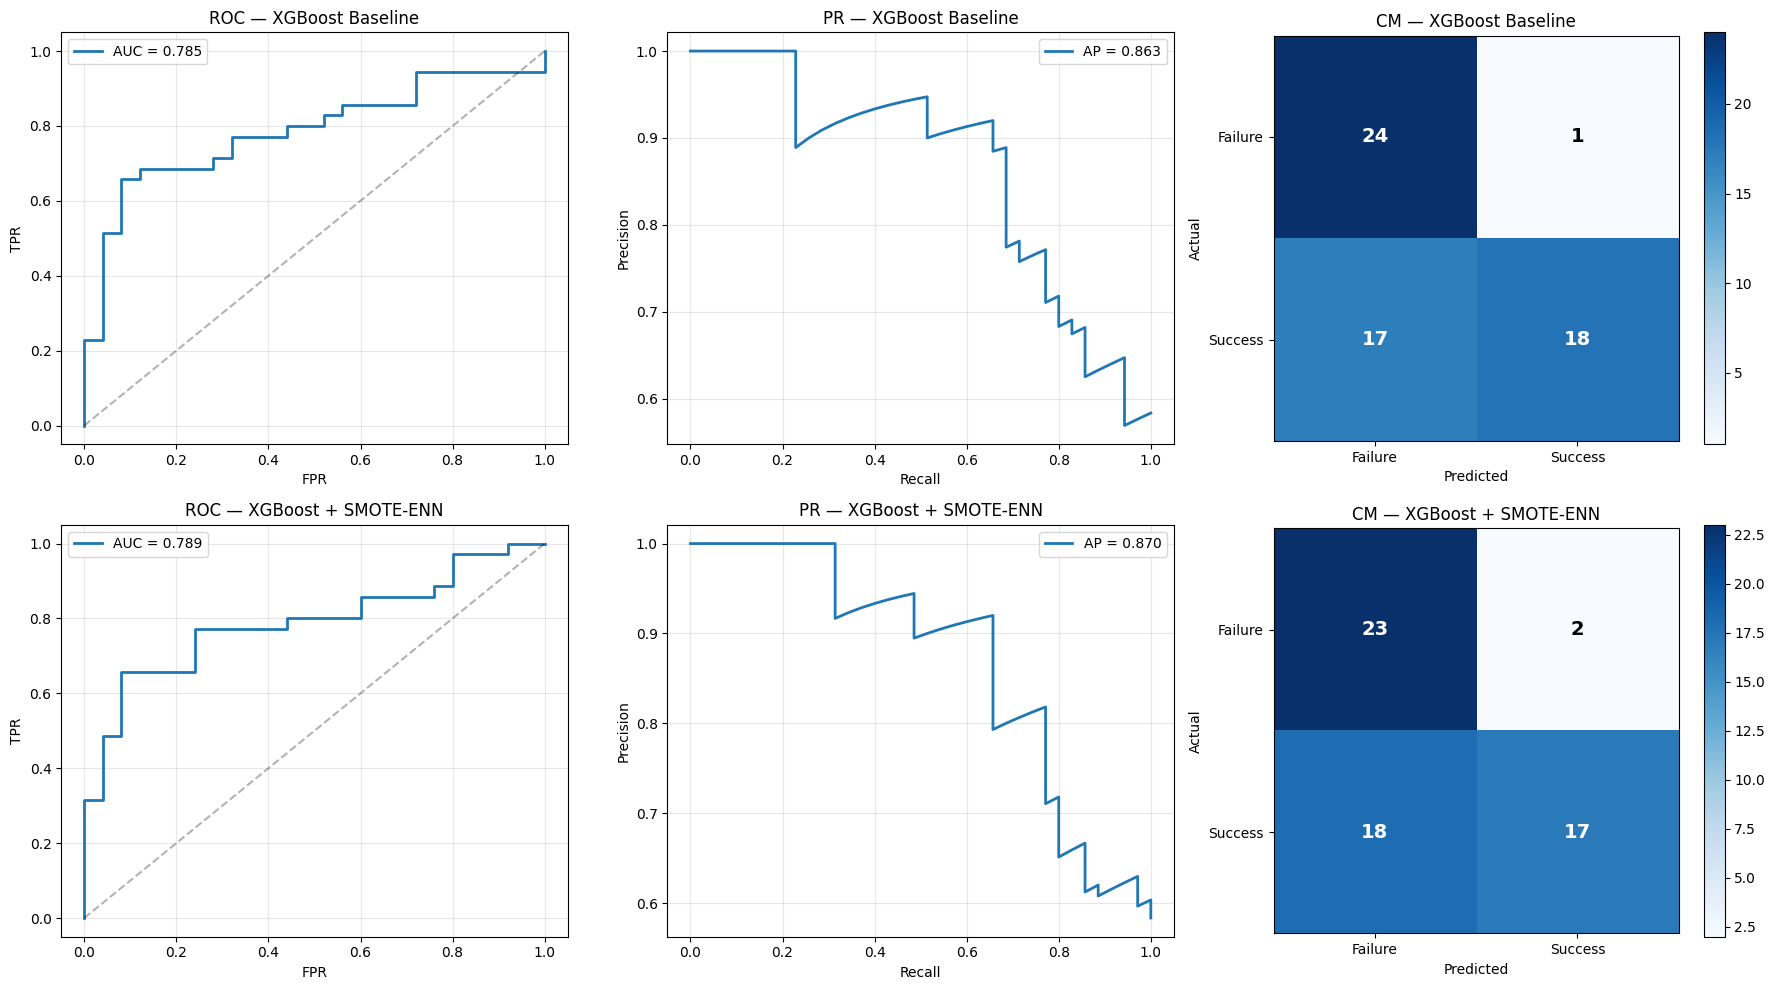

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (probs_eval, labels_eval, cm_eval, title) in enumerate([
    (xgb_bl_probs, xgb_bl_labels, xgb_bl_cm, "XGBoost Baseline"),
    (xgb_sm_probs, xgb_sm_labels, xgb_sm_cm, "XGBoost + SMOTE-ENN"),
]):
    # ROC Curve
    try:
        fpr, tpr, _ = roc_curve(labels_eval, probs_eval)
        auc_val = roc_auc_score(labels_eval, probs_eval)
        axes[row, 0].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}")
        axes[row, 0].plot([0, 1], [0, 1], "k--", alpha=0.3)
    except ValueError:
        axes[row, 0].text(0.5, 0.5, "Insufficient data", ha="center", va="center")
    axes[row, 0].set_xlabel("FPR")
    axes[row, 0].set_ylabel("TPR")
    axes[row, 0].set_title(f"ROC — {title}")
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    # PR Curve
    try:
        prec, rec, _ = precision_recall_curve(labels_eval, probs_eval)
        ap = average_precision_score(labels_eval, probs_eval)
        axes[row, 1].plot(rec, prec, linewidth=2, label=f"AP = {ap:.3f}")
    except ValueError:
        axes[row, 1].text(0.5, 0.5, "Insufficient data", ha="center", va="center")
    axes[row, 1].set_xlabel("Recall")
    axes[row, 1].set_ylabel("Precision")
    axes[row, 1].set_title(f"PR — {title}")
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)

    # Confusion Matrix
    im = axes[row, 2].imshow(cm_eval, cmap="Blues", interpolation="nearest")
    axes[row, 2].set_title(f"CM — {title}")
    axes[row, 2].set_xlabel("Predicted")
    axes[row, 2].set_ylabel("Actual")
    axes[row, 2].set_xticks([0, 1])
    axes[row, 2].set_yticks([0, 1])
    axes[row, 2].set_xticklabels(["Failure", "Success"])
    axes[row, 2].set_yticklabels(["Failure", "Success"])
    for i in range(2):
        for j in range(2):
            axes[row, 2].text(j, i, str(cm_eval[i][j]),
                              ha="center", va="center",
                              color="white" if cm_eval[i][j] > cm_eval.max() / 2 else "black",
                              fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=axes[row, 2])

plt.tight_layout()
plt.savefig(MODEL_DIR / "xgb_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature Importance

A key advantage of XGBoost over LSTM — built-in feature importance reveals **which clinical factors matter most** for predicting treatment outcome. This is crucial for a CDSS where clinicians need to understand *why* a prediction was made.

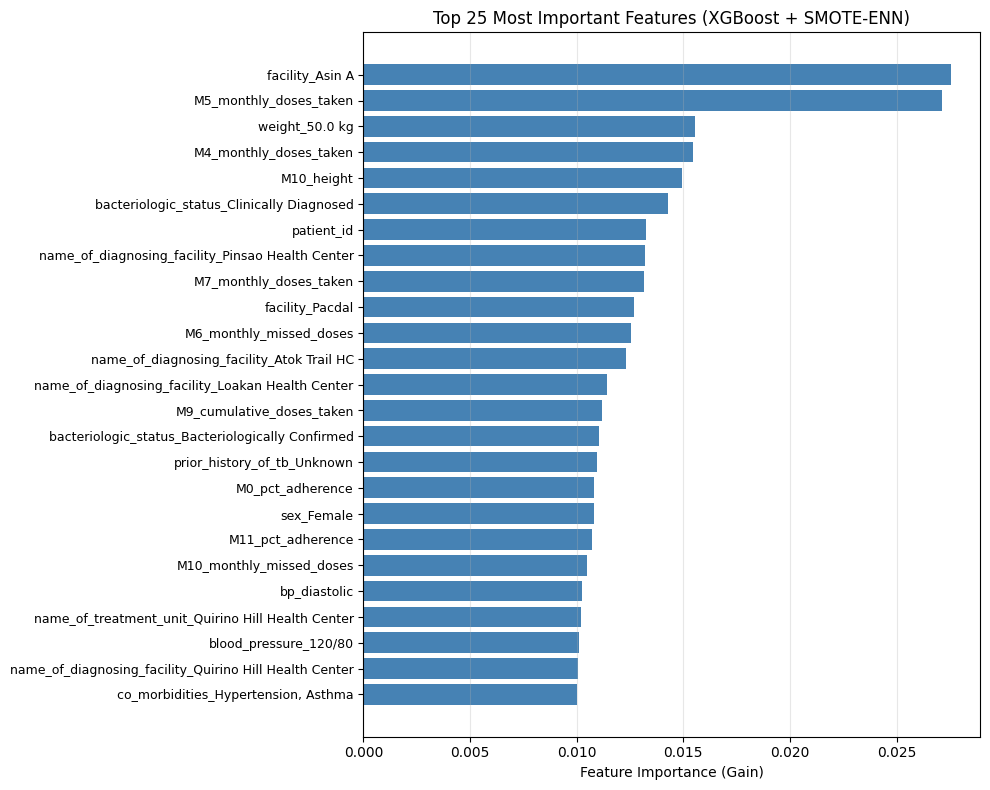


Feature importance by category:
  Static (baseline)             : 0.4944 (49.4%)
  Temporal (raw monthly)        : 0.4998 (50.0%)
  Aggregate (mean/std/min/max)  : 0.0058 (0.6%)
  Trend (slopes)                : 0.0000 (0.0%)
  Latest month                  : 0.0000 (0.0%)


In [10]:
# Use the SMOTE-ENN model as the primary XGBoost for feature importance
xgb_model = xgb_smote_model
optimal_threshold = xgb_smote_thresh
metrics = xgb_smote_metrics
probs = xgb_sm_probs
preds = xgb_sm_preds
labels = xgb_sm_labels
cm = xgb_sm_cm

# Get feature importance
importances = xgb_model.feature_importances_

if len(feature_names_xgb) < len(importances):
    feature_names_xgb_padded = feature_names_xgb + [
        f"pad_{i}" for i in range(len(importances) - len(feature_names_xgb))
    ]
else:
    feature_names_xgb_padded = feature_names_xgb[:len(importances)]

importance_df = pd.DataFrame({
    "feature": feature_names_xgb_padded,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 25
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(top_n), top_features["importance"].values[::-1], color="steelblue")
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"].values[::-1], fontsize=9)
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title(f"Top {top_n} Most Important Features (XGBoost + SMOTE-ENN)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(MODEL_DIR / "xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Categorize feature importance
print("\nFeature importance by category:")
categories = {
    "Static (baseline)": [f for f in importance_df["feature"] if not any(
        f.startswith(p) for p in ["M", "mean_", "std_", "min_", "max_",
                                   "trend_", "latest_", "months_"])],
    "Temporal (raw monthly)": [f for f in importance_df["feature"] if f[:1] == "M" and "_" in f],
    "Aggregate (mean/std/min/max)": [f for f in importance_df["feature"]
                                       if any(f.startswith(p) for p in ["mean_", "std_", "min_", "max_"])],
    "Trend (slopes)": [f for f in importance_df["feature"] if f.startswith("trend_")],
    "Latest month": [f for f in importance_df["feature"] if f.startswith("latest_")],
}

for cat_name, cat_features in categories.items():
    cat_importance = importance_df[importance_df["feature"].isin(cat_features)]["importance"].sum()
    print(f"  {cat_name:<30s}: {cat_importance:.4f} "
          f"({cat_importance / importances.sum() * 100:.1f}%)")

## 7. CDSS Predictions

Generate per-patient predictions with **confidence scores** and **risk levels** for all 205 patients using full M0–M12 data.

In [11]:
def generate_cdss_predictions_xgb(model, X_temporal_all, X_static_all, df,
                                  up_to_month, temporal_names, static_names,
                                  n_features_full, threshold=0.5):
    """Generate per-patient CDSS predictions with confidence and risk levels."""

    probs = predict_at_month_xgb(
        model, X_temporal_all, X_static_all,
        up_to_month=up_to_month,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )

    results = []
    for i in range(len(df)):
        prob_success = float(probs[i])
        prob_failure = 1.0 - prob_success
        predicted_class = "Success" if prob_success >= threshold else "Failure"
        confidence = max(prob_success, prob_failure) * 100

        if prob_failure >= 0.7:
            risk_level = "HIGH RISK"
        elif prob_failure >= 0.4:
            risk_level = "MODERATE RISK"
        else:
            risk_level = "LOW RISK"

        results.append({
            "patient_idx": i,
            "treatment_regimen": df.iloc[i].get("treatment_regimen", "N/A"),
            "actual_outcome": df.iloc[i]["outcome"],
            "predicted_outcome": predicted_class,
            "prob_success": round(prob_success, 4),
            "prob_failure": round(prob_failure, 4),
            "confidence_pct": round(confidence, 2),
            "risk_level": risk_level,
            "months_used": f"M0-M{up_to_month}",
        })

    return pd.DataFrame(results)


predictions_df = generate_cdss_predictions_xgb(
    xgb_model, X_temporal, X_static, df,
    up_to_month=12,
    temporal_names=temporal_names,
    static_names=static_names,
    n_features_full=n_features_full,
    threshold=optimal_threshold,
)
predictions_df.to_csv(MODEL_DIR / "xgb_predictions.csv", index=False)

print(f"Predictions saved to models/xgb_predictions.csv")
print(f"Classification threshold: {optimal_threshold:.2f}")
print(f"\nRisk Level Distribution:")
print(predictions_df["risk_level"].value_counts())
print(f"\nSample predictions:")
predictions_df.head(10)

Predictions saved to models/xgb_predictions.csv
Classification threshold: 0.75

Risk Level Distribution:
risk_level
LOW RISK         353
HIGH RISK        166
MODERATE RISK     80
Name: count, dtype: int64

Sample predictions:


,patient_idx,treatment_regimen,actual_outcome,predicted_outcome,prob_success,prob_failure,confidence_pct,risk_level,months_used
0,0,1.0,Treatment Completed,Success,0.9473,0.0527,94.73,LOW RISK,M0-M12
1,1,1.0,Treatment Completed,Failure,0.4837,0.5163,51.63,MODERATE RISK,M0-M12
2,2,NaN,Lost to Follow Up,Failure,0.1741,0.8259,82.59,HIGH RISK,M0-M12
3,3,NaN,Treatment Completed,Success,0.9673,0.0327,96.73,LOW RISK,M0-M12
4,4,NaN,Treatment Completed,Success,0.9301,0.0699,93.01,LOW RISK,M0-M12
5,5,NaN,Cured,Success,0.9634,0.0366,96.34,LOW RISK,M0-M12
6,6,NaN,Treatment Completed,Success,0.8408,0.1592,84.08,LOW RISK,M0-M12
7,7,1.0,NaN,Failure,0.6589,0.3411,65.89,LOW RISK,M0-M12
8,8,1.0,Treatment Completed,Success,0.9042,0.0958,90.42,LOW RISK,M0-M12
9,9,1.0,Treatment Completed,Success,0.8993,0.1007,89.93,LOW RISK,M0-M12


## 8. CDSS Early Warning — Predict at Any Month

Demonstrate progressive prediction for a single patient, showing how confidence evolves as more monthly data becomes available.

In [12]:
print("CDSS DEMO — Progressive Early Warning for Patient 0 (XGBoost + SMOTE-ENN)")
print(f"Actual outcome: {df.iloc[0]['outcome']}")
print(f"Regimen: {df.iloc[0]['treatment_regimen']}")
print(f"Threshold: {optimal_threshold:.2f}")
print("=" * 65)
print()

for month in range(0, 13):
    # Build features for this single patient up to this month
    probs_m = predict_at_month_xgb(
        xgb_model,
        X_temporal[0:1], X_static[0:1],
        up_to_month=month,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )
    prob_s = probs_m[0]
    confidence = max(prob_s, 1 - prob_s) * 100
    predicted = "Success" if prob_s >= optimal_threshold else "Failure"
    bar = "█" * int(prob_s * 30)
    print(f"  After M{month:>2d}: {predicted:<8s}  "
          f"Confidence={confidence:>5.1f}%  "
          f"P(Success)={prob_s:.3f}  {bar}")

CDSS DEMO — Progressive Early Warning for Patient 0 (XGBoost + SMOTE-ENN)
Actual outcome: Treatment Completed
Regimen: 1.0
Threshold: 0.75

  After M 0: Success   Confidence= 91.4%  P(Success)=0.914  ███████████████████████████
  After M 1: Success   Confidence= 91.7%  P(Success)=0.917  ███████████████████████████
  After M 2: Success   Confidence= 93.8%  P(Success)=0.938  ████████████████████████████
  After M 3: Success   Confidence= 90.9%  P(Success)=0.909  ███████████████████████████
  After M 4: Success   Confidence= 94.8%  P(Success)=0.948  ████████████████████████████
  After M 5: Success   Confidence= 94.4%  P(Success)=0.944  ████████████████████████████
  After M 6: Success   Confidence= 94.7%  P(Success)=0.947  ████████████████████████████
  After M 7: Success   Confidence= 94.8%  P(Success)=0.948  ████████████████████████████
  After M 8: Success   Confidence= 94.3%  P(Success)=0.943  ████████████████████████████
  After M 9: Success   Confidence= 94.7%  P(Success)=0.947  ██

### Per-Month Prediction Accuracy (Temporal Evaluation)

Evaluate prediction quality at each month M0–M12 across all test patients — directly comparable to the LSTM's per-month evaluation.

Per-month — XGBoost Baseline (threshold=0.71):
month  accuracy       f1  specificity      auc  n_correct  n_total
   M0  0.500000 0.285714         0.96 0.742857         30       60
   M1  0.516667 0.408163         0.84 0.755429         31       60
   M2  0.516667 0.382979         0.88 0.794286         31       60
   M3  0.566667 0.480000         0.88 0.798857         34       60
   M4  0.600000 0.500000         0.96 0.748571         36       60
   M5  0.700000 0.666667         0.96 0.787429         42       60
   M6  0.666667 0.615385         0.96 0.795429         40       60
   M7  0.700000 0.666667         0.96 0.776000         42       60
   M8  0.700000 0.666667         0.96 0.781714         42       60
   M9  0.700000 0.666667         0.96 0.790857         42       60
  M10  0.700000 0.666667         0.96 0.784000         42       60
  M11  0.700000 0.666667         0.96 0.785143         42       60
  M12  0.700000 0.666667         0.96 0.785143         42       60

Per-month — XG

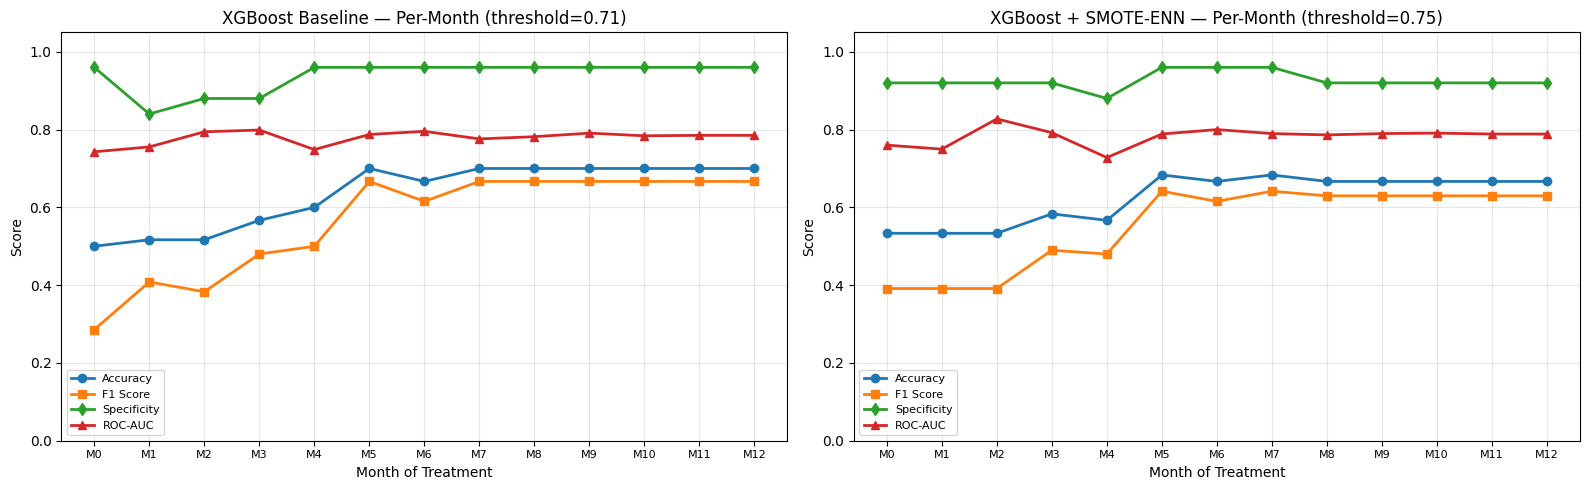

In [13]:
test_temporal = X_temporal[test_idx]
test_static = X_static[test_idx]
test_labels = y[test_idx]

# Per-month for baseline
xgb_bl_monthly = evaluate_per_month_xgb(
    xgb_baseline_model, test_temporal, test_static, test_labels,
    temporal_names, static_names, n_features_full,
    threshold=xgb_baseline_thresh,
)

# Per-month for SMOTE-ENN
xgb_sm_monthly = evaluate_per_month_xgb(
    xgb_smote_model, test_temporal, test_static, test_labels,
    temporal_names, static_names, n_features_full,
    threshold=xgb_smote_thresh,
)

print(f"Per-month — XGBoost Baseline (threshold={xgb_baseline_thresh:.2f}):")
print(xgb_bl_monthly.to_string(index=False))
print(f"\nPer-month — XGBoost + SMOTE-ENN (threshold={xgb_smote_thresh:.2f}):")
print(xgb_sm_monthly.to_string(index=False))

# Plot per-month comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, perf, title, thresh in [
    (axes[0], xgb_bl_monthly, "XGBoost Baseline", xgb_baseline_thresh),
    (axes[1], xgb_sm_monthly, "XGBoost + SMOTE-ENN", xgb_smote_thresh),
]:
    ax.plot(range(13), perf["accuracy"], "o-", label="Accuracy", linewidth=2)
    ax.plot(range(13), perf["f1"], "s-", label="F1 Score", linewidth=2)
    ax.plot(range(13), perf["specificity"], "d-", label="Specificity", linewidth=2)
    ax.plot(range(13), perf["auc"], "^-", label="ROC-AUC", linewidth=2)
    ax.set_xlabel("Month of Treatment")
    ax.set_ylabel("Score")
    ax.set_title(f"{title} — Per-Month (threshold={thresh:.2f})")
    ax.set_xticks(range(13))
    ax.set_xticklabels([f"M{i}" for i in range(13)], fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(MODEL_DIR / "xgb_per_month_performance.png", dpi=150, bbox_inches="tight")
plt.show()

# Keep reference for comparison
monthly_perf = xgb_sm_monthly  # primary XGBoost model

## 9. Cross-Validation (Robustness Check)

With only 205 patients, a single train/test split can be unreliable. Stratified 5-fold cross-validation provides a more robust estimate of model performance.

In [14]:
# Build full M12 features for all patients
X_all_full, _ = build_features_at_month(
    X_temporal, X_static, up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)

# Class weight
n_pos = y.sum()
n_neg = len(y) - n_pos
spw = n_neg / n_pos

cv_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw,
    eval_metric="logloss",
    random_state=SEED,
    use_label_encoder=False,
    verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring_metrics = ["accuracy", "f1", "roc_auc", "precision", "recall"]
print("5-Fold Stratified Cross-Validation Results (M12 features):")
print("-" * 55)

cv_results = {}
for metric in scoring_metrics:
    scores = cross_val_score(cv_model, X_all_full, y, cv=cv, scoring=metric)
    cv_results[metric] = scores
    print(f"  {metric:<12s}: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"(folds: {', '.join(f'{s:.3f}' for s in scores)})")

print(f"\nCompare with LSTM test results:")
print(f"  LSTM  ROC-AUC: 0.1579  (single test split)")
print(f"  XGB   ROC-AUC: {cv_results['roc_auc'].mean():.4f} ± {cv_results['roc_auc'].std():.4f}  (5-fold CV)")

5-Fold Stratified Cross-Validation Results (M12 features):
-------------------------------------------------------
  accuracy    : 0.7312 ± 0.0377  (folds: 0.717, 0.800, 0.692, 0.708, 0.739)
  f1          : 0.7734 ± 0.0356  (folds: 0.750, 0.838, 0.748, 0.745, 0.786)
  roc_auc     : 0.8092 ± 0.0347  (folds: 0.779, 0.875, 0.783, 0.799, 0.809)
  precision   : 0.7606 ± 0.0263  (folds: 0.773, 0.795, 0.714, 0.761, 0.760)
  recall      : 0.7886 ± 0.0588  (folds: 0.729, 0.886, 0.786, 0.729, 0.814)

Compare with LSTM test results:
  LSTM  ROC-AUC: 0.1579  (single test split)
  XGB   ROC-AUC: 0.8092 ± 0.0347  (5-fold CV)


## 10. Save Model Config & Evaluation Report

## 9. Export to ONNX and ORT

Export the trained XGBoost model to ONNX and ORT formats for web browser deployment.


In [15]:
# Reload model_utils to get the updated export function
import importlib
import sys
if 'model_utils' in sys.modules:
    del sys.modules['model_utils']

from model_utils import export_tree_model_to_onnx

# Prepare dummy sample for ONNX validation
X_dummy, _ = build_features_at_month(
    X_temporal[:1], X_static[:1], up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)

# Export to ONNX and ORT
print(f"\n{'='*55}")
print(f"  Exporting XGBoost Model to ONNX/ORT")
print(f"{'='*55}")

export_result = export_tree_model_to_onnx(
    fitted_pipeline=xgb_smote_model,
    feature_names=feature_names_xgb,
    model_name="xgboost_temporal",
    output_dir=MODEL_DIR,
    X_dummy_sample=X_dummy,
)

if export_result['onnx_path']:
    print(f"✓ ONNX: {export_result['onnx_path']}")
    print(f"✓ ORT:  {export_result['ort_path']}")
    print(f"✓ Features: {len(export_result['feature_names'])} dimensions")
    
    # Quick verification: load ONNX and test inference
    import onnxruntime as ort
    
    # Use ONNX file directly (ORT file might have format differences)
    onnx_model_path = export_result['onnx_path']
    try:
        ort_session = ort.InferenceSession(
            str(onnx_model_path),
            providers=['CPUExecutionProvider']
        )
        
        # Test with dummy batch
        X_test_batch = X_dummy[:5].astype(np.float32)
        input_name = ort_session.get_inputs()[0].name
        ort_inputs = {input_name: X_test_batch}
        ort_outputs = ort_session.run(None, ort_inputs)
        ort_probs = ort_outputs[0]
        
        print(f"\n✓ ONNX Inference Verification:")
        print(f"  Input shape:  {X_test_batch.shape}")
        print(f"  Output shape: {ort_probs.shape}")
        print(f"  Sample predictions: {ort_probs[:3].flatten()}")
        print(f"  Output range: [{ort_probs.min():.4f}, {ort_probs.max():.4f}]")
        print(f"\n✓ Model is ready for web deployment")
        print(f"  Use .onnx file with ONNX Runtime in browser or Node.js")
    except Exception as e:
        print(f"\n⚠ Inference test failed: {type(e).__name__}: {str(e)[:100]}")
        print(f"  ONNX file is still valid, may be format/provider issue")
else:
    print(f"✗ ONNX export failed — Using joblib checkpoint instead")
    if 'checkpoint_path' in export_result and export_result['checkpoint_path']:
        print(f"✓ Model checkpoint available: {export_result['checkpoint_path']}")
        print(f"\nFor web deployment:")
        print(f"  Use: model = joblib.load('{export_result['checkpoint_path']}')")
        print(f"  Then: probs = model.predict_proba(X)")
        print(f"  Or use Node.js with Python subprocess to call the model")


  Exporting XGBoost Model to ONNX/ORT
Converting xgboost_temporal to ONNX (detected: XGBClassifier from xgboost.sklearn)...
  Using onnxmltools for XGBClassifier conversion...
  ⚠ onnxmltools failed: RuntimeError: Operator XGBClassifier (type: XGBClassifier) got an input float_input with a wrong type <class 'skl2
  Attempting alternative: use sklearn wrapper directly on dummy data...
  ⚠ Wrapper approach failed: MissingShapeCalculator: Unable to find a shape calculator for type '<class 'model_utils.export_tree_model_to_onnx.<locals>.X
  Saving checkpoint instead...
  ✓ Model checkpoint saved: xgboost_temporal_checkpoint.joblib
  Note: Use joblib.load() for inference instead of ONNX Runtime
✗ ONNX export failed — Using joblib checkpoint instead
✓ Model checkpoint available: c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\xgboost\xgboost_temporal_checkpoint.joblib

For web deployment:
  Use: model = joblib.load('c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\mod

In [16]:
# ── Save model configs ───────────────────────────────────────────
config = {
    "models_trained": [
        "XGBoost (Baseline)",
        "XGBoost + SMOTE-ENN",
    ],
    "xgboost_params": {
        "n_estimators": 300, "max_depth": 4, "learning_rate": 0.05,
        "min_child_weight": 3, "subsample": 0.8, "colsample_bytree": 0.8,
        "reg_alpha": 0.1, "reg_lambda": 1.0,
    },
    "augmentation": "SMOTE-ENN (Synthetic Minority Oversampling + Edited Nearest Neighbors)",
    "n_features": int(n_features_full),
    "n_patients": int(len(y)),
    "train_patients": int(len(train_idx)),
    "val_patients": int(len(val_idx)),
    "test_patients": int(len(test_idx)),
    "training_mode": "progressive_temporal (one sample per patient per month, M0-M12)",
    "split": "70/20/10 (patient-level, stratified — identical to LSTM)",
    "seed": SEED,
    "thresholds": {
        "xgb_baseline": float(xgb_baseline_thresh),
        "xgb_smote_enn": float(xgb_smote_thresh),
    },
    "static_feature_names": static_names,
    "temporal_feature_names": temporal_names,
}
with open(MODEL_DIR / "xgb_model_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("✓ models/xgb_model_config.json")

# ── Save evaluation report ──────────────────────────────────────
report_lines = [
    "TB-DOTS CAR CDSS — XGBoost Evaluation Report",
    "(Baseline vs SMOTE-ENN Augmented)",
    "=" * 60,
    f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"Dataset: {len(y)} patients, split 70/20/10 (patient-level, stratified)",
    f"Training mode: Progressive temporal — 13 samples/patient (M0..M12)",
    f"Features: {n_features_full} (static + engineered temporal + aggregates + trends)",
    f"Augmentation: SMOTE-ENN (SMOTE + Edited Nearest Neighbors)",
    "",
]

# Both XGBoost variants
all_results = [
    ("XGBoost (Baseline)", xgb_baseline_metrics, xgb_baseline_thresh, xgb_bl_cm),
    ("XGBoost + SMOTE-ENN", xgb_smote_metrics, xgb_smote_thresh, xgb_sm_cm),
]

for model_name, model_metrics, thresh, model_cm in all_results:
    report_lines.extend([
        f"\n{'='*55}",
        f"  {model_name} (threshold={thresh:.2f})",
        f"{'='*55}",
    ])
    for k, v in model_metrics.items():
        report_lines.append(f"  {k:<14s} : {v:.4f}")
    report_lines.extend([
        "",
        "Confusion Matrix:",
        str(model_cm),
    ])

# Comparison table
metric_names = ["accuracy", "precision", "recall", "f1",
                "specificity", "roc_auc", "pr_auc"]
report_lines.extend([
    "",
    "=" * 60,
    "BASELINE vs SMOTE-ENN COMPARISON",
    "=" * 60,
    "",
    f"{'Metric':<14s}  {'Baseline':>12s}  {'SMOTE-ENN':>12s}",
    "-" * 46,
])
for metric in metric_names:
    bl_v = xgb_baseline_metrics.get(metric, float("nan"))
    sm_v = xgb_smote_metrics.get(metric, float("nan"))
    report_lines.append(f"  {metric:<12s}  {bl_v:>12.4f}  {sm_v:>12.4f}")

# Per-month results
for model_name, monthly_df in [
    ("XGBoost Baseline", xgb_bl_monthly),
    ("XGBoost + SMOTE-ENN", xgb_sm_monthly),
]:
    report_lines.extend([
        "",
        f"Per-Month Performance — {model_name}:",
        "-" * 40,
        monthly_df.to_string(index=False),
    ])

with open(MODEL_DIR / "xgb_evaluation_report.txt", "w") as f:
    f.write("\n".join(report_lines))
print("✓ models/xgb_evaluation_report.txt")

# ── Save metrics as JSON ────────────────────────────────────────
xgb_metrics_export = {
    "XGB Baseline": {k: float(v) for k, v in xgb_baseline_metrics.items()},
    "XGB SMOTE-ENN": {k: float(v) for k, v in xgb_smote_metrics.items()},
}
xgb_metrics_export["XGB Baseline"]["threshold"] = float(xgb_baseline_thresh)
xgb_metrics_export["XGB SMOTE-ENN"]["threshold"] = float(xgb_smote_thresh)
with open(MODEL_DIR / "xgb_metrics.json", "w") as f:
    json.dump(xgb_metrics_export, f, indent=2)
print("✓ models/xgb_metrics.json")

print("\nAll saved files:")
print("  ✓ models/xgb_baseline_model.json")
print("  ✓ models/xgb_smote_model.json")
print("  ✓ models/xgb_model_config.json")
print("  ✓ models/xgb_evaluation_report.txt")
print("  ✓ models/xgb_metrics.json")
print("  ✓ models/xgb_predictions.csv")
print("  ✓ models/xgb_training_curves.png")
print("  ✓ models/xgb_evaluation_plots.png")
print("  ✓ models/xgb_feature_importance.png")
print("  ✓ models/xgb_per_month_performance.png")

✓ models/xgb_model_config.json
✓ models/xgb_evaluation_report.txt
✓ models/xgb_metrics.json

All saved files:
  ✓ models/xgb_baseline_model.json
  ✓ models/xgb_smote_model.json
  ✓ models/xgb_model_config.json
  ✓ models/xgb_evaluation_report.txt
  ✓ models/xgb_metrics.json
  ✓ models/xgb_predictions.csv
  ✓ models/xgb_training_curves.png
  ✓ models/xgb_evaluation_plots.png
  ✓ models/xgb_feature_importance.png
  ✓ models/xgb_per_month_performance.png
